# Введение

В данной лабораторной работе рассматриваются численные методы решения систем линейных алгебраических уравнений (СЛАУ). Особое внимание уделяется сравнению точных и итерационных методов, а также исследованию их устойчивости и сходимости при различных условиях.

## Точные методы

Реализуются следующие точные методы решения СЛАУ:
- Метод Гаусса с частичным выбором главного элемента
- LU-разложение
- Разложение Холецкого для симметричных положительно определённых матриц

## Метод Гаусса с частичным выбором ведущего элемента

### Краткое описание

**Прямой ход:** 
- Сводим матрицу к верхнетреугольному виду
- Для повышения точности переупорядочиваем строки, выбирая максимальный по модулю

**Обратный ход:**
- Начиная с низа матрицы, определяем неизвестные
- Последовательно переходим к верхним уравнениям

### Формула обратного хода

Для системы с верхнетреугольной матрицей \( U \), решение вычисляется по формуле:

$$x_i = \frac{b_i - \sum_{j=i+1}^{n} u_{ij} \cdot x_j}{u_{ii}}, \quad i = n, n-1, \ldots, 1$$

где:
- $x_i$ - искомая переменная
- $u_{ij}$ - элементы верхнетреугольной матрицы
- $b_i$ - элементы правой части системы
- $n$ - размерность системы

### Особенности
Алгоритм обеспечивает надёжное решение систем линейных уравнений с учётом числовой устойчивости за счёт частичного выбора главного элемента.

### Особенности реализации
Программа написана с учётом генерации матриц только с целыми числами и целыми ответами. Это сделано для простоты использования.

In [177]:
import numpy as np

def gaussian_with_partial_choice(matrix, result):
    # Узнаём размерность матрицы
    n = len(result)
    # Дополняем матрицу до расширенной
    Ab = np.hstack([matrix.astype(float), result.reshape(-1, 1).astype(float)])
    
    # Перебираем строки в поисках главного элемента
    for i in range(n):
        # Выбираем наибольший по модулю элемент
        max_row = np.argmax(np.abs(Ab[i:, i])) + i
        if max_row != i:
            Ab[[i, max_row]] = Ab[[max_row, i]]
        
        # перебираем остальные строки и приводим матрицу к верхнетреугольному виду.
        for j in range(i + 1, n):
            k = Ab[j, i] / Ab[i, i]
            Ab[j, i:] -= k * Ab[i, i:]
    
    # Создаём вектор из нулей
    answer = np.zeros(n)
    for i in range(n-1, -1, -1):
        # Вычмсляем значения и решаем СЛАУ
        answer[i] = (Ab[i, -1] - np.dot(Ab[i, i+1:n], answer[i+1:n])) / Ab[i, i]
    
    # Округляем до целых чисел и преобразуем к целому типу
    return np.round(answer).astype(int)

def generate_slau(n, seed=47):
    #генерация матрицы по сиду, чтобы иметь возможность повторно увидеть какой-либо результат
    np.random.seed(seed)
    A = np.random.randint(-10, 11, (n, n))
    # Генерация коеффициентов
    for i in range(n):
        A[i, i] = np.sum(np.abs(A[i, :])) + 1
    # Генерация значений переменных
    x_true = np.random.randint(-5, 6, n)
    # Формирование слобца с ответами
    b = (A @ x_true).astype(int)
    return A, b, x_true

if __name__ == "__main__":
    print("Проверка при n = 10:")
    A, b, x_true = generate_slau(10)
    print("\nA:\n", A)
    print("\nb:\n", b)
    ans = gaussian_with_partial_choice(A, b)
    print("\nans:\n", ans)
    print("\nx_true\n", x_true)
    print("*"*50)
    print("\nПроверка при n = 50:")
    A, b, x_true = generate_slau(50)
    print("\nA:\n", A)
    print("\nb:\n", b)
    ans = gaussian_with_partial_choice(A, b)
    print("\nans:\n", ans)
    print("\nx_true\n", x_true)
    print("*"*50)
    print("Корректность работы:", all(x_true == ans))



Проверка при n = 10:

A:
 [[ 42  -4  -3  -2  -2   9   6   6  -3  -3]
 [  3  58   8   8   1  -9  10  -2  -1   8]
 [ -1  -9  61  -1  -8 -10  -8   4   7  -6]
 [ -7  10  -5  52  -4   5  -9   9   1   0]
 [  0   1  -1   3  45  -7  -6   2   9  -9]
 [ 10  10   1  -8  -8  66  -1   6  -9  -6]
 [  6   5  -4  -4   8   8  50  -2   2   2]
 [-10  -6  10   3  -4  10   3  58   3  -1]
 [ -2  -9  -3   6   4   7   1  -1  46   4]
 [ -8  -3  -2  -2   1  -2  -8   9   1  47]]

b:
 [ 115 -252 -170 -181  235 -215 -185  -76 -156 -139]

ans:
 [ 3 -3 -4 -3  4 -4 -4  1 -3 -4]

x_true
 [ 3 -3 -4 -3  4 -4 -4  1 -3 -4]
**************************************************

Проверка при n = 50:

A:
 [[254  -4  -3 ...   2   9  -9]
 [ 10 263   1 ...   9   1  10]
 [ -2  -8 264 ...  -1   9   4]
 ...
 [ -2   0  -7 ... 274  10   8]
 [  7   0  10 ...  -5 260  -3]
 [ -7 -10  -7 ...  -3  -7 253]]

b:
 [ -262 -1152  1287   -18   316  -301  -283  -438   489  1309   796  -453
  1033 -1277  -813 -1167  -591  -403  -601   529  -174   1

## LU-разложение:

**LU-разложение** - это представление матрицы A в виде произведения двух матриц:
- **L** (Lower) - нижняя треугольная матрица с единицами на диагонали
- **U** (Upper) - верхняя треугольная матрица

**Формула:** A = L × U

**Преимущества:**
- Один раз разложив матрицу, можно быстро решать системы с разными правыми частями
- Упрощает вычисление определителя и обратной матрицы
- Более эффективно чем многократное применение метода Гаусса
**Алгоритм:**
1. Инициализировать L как единичную матрицу, U как нулевую
2. Для каждого элемента матрицы:
   - Если элемент на/выше диагонали → вычисляем U[i,j]
   - Если элемент ниже диагонали → вычисляем L[i,j]

In [178]:
def lu_decomposition(A):
    n = A.shape[0]          # Размерность матрицы
    L = np.eye(n)           # Инициализация L как единичной матрицы
    U = np.zeros((n, n))    # Инициализация U как нулевой матрицы
    
    # Проход по всем элементам матрицы
    for i in range(n):
        for j in range(n):
            if j >= i:
                # Вычисление элементов U (верхний треугольник и диагональ)
                U[i, j] = A[i, j] - np.dot(L[i, :i], U[:i, j])
            if i > j:
                # Вычисление элементов L (нижний треугольник)
                L[i, j] = (A[i, j] - np.dot(L[i, :j], U[:j, j])) / U[j, j]
    
    return L, U

def solve_lu(A, b):
    try:
        # Выполняем LU-разложение матрицы A
        L, U = lu_decomposition(A)
        # Проверка диагональных элементов U на вырожденность
        for i in range(U.shape[0]):
            if abs(U[i, i]) < 1e-12:
                raise ValueError("Нулевой диагональный элемент")
        
        # Прямая подстановка: решение системы L*y = b
        n = len(b)
        y = np.zeros(n)  # Вектор промежуточных переменных
        y[0] = b[0] / L[0, 0]
        # Остальные уравнения: для k от 1 до n-1
        for k in range(1, n):
            y[k] = (b[k] - np.dot(L[k, :k], y[:k])) / L[k, k]
        
        # Обратная подстановка: решение системы U*x = y
        x = np.zeros(n)  # Вектор решения
        # Последнее уравнение
        x[-1] = y[-1] / U[-1, -1]
        # Остальные уравнения: для k от n-2 до 0 (снизу вверх)
        for k in range(n-2, -1, -1):
            x[k] = (y[k] - np.dot(U[k, k+1:], x[k+1:])) / U[k, k]
        
        return x
        
    except ValueError as e:
        # Обработка ошибки при вырожденной матрице
        print("Ошибка LU-разложения:", e)
        return None

if __name__ == "__main__":
    # Тестовая матрица и вектор правой части
    A = np.array([
        [1, 3, 3],
        [4, 5, 6],
        [7, 8, 10]
    ], dtype=float)
    
    b = np.array([1, 2, 3], dtype=float)
    
    print("Исходная матрица A:\n", A)
    print("\nВектор b:\n", b)
    
    # Решение системы LU-разложением
    answer = solve_lu(A, b)
    print("\nВычисление:\n", answer)

Исходная матрица A:
 [[ 1.  3.  3.]
 [ 4.  5.  6.]
 [ 7.  8. 10.]]

Вектор b:
 [1. 2. 3.]

Вычисление:
 [ 1.  2. -2.]


# Разложение Холецкого

**Принцип:** A = L × Lᵀ  
где L - нижняя треугольная матрица

**Цель:** Эффективное решение симметричных положительно определенных систем

**Преимущества:**
- В 2 раза быстрее LU-разложения
- Гарантированно устойчиво
- Проще вычислять определитель

**Ограничение:** Только для симметричных положительно определенных матриц

In [179]:
# Разложение Холецкого для симметричной положительно определенной матрицы A = L * L^T
def cholesky_decomposition(A):
    n = A.shape[0]
    L = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i + 1):
            if i == j:
                # Диагональные элементы
                sum_sq = np.sum(L[i, :j]**2)
                L[i, j] = np.sqrt(A[i, i] - sum_sq)
            else:
                # Недиагональные элементы
                sum_prod = np.sum(L[i, :j] * L[j, :j])
                L[i, j] = (A[i, j] - sum_prod) / L[j, j]
    
    return L

def is_symmetric_positive_definite(A):
    # Проверка симметричности
    if not np.allclose(A, A.T):
        return False, "Матрица не симметричная"
    # Проверка положительной определенности через собственные значения
    eigenvalues = np.linalg.eigvals(A)
    if np.any(eigenvalues <= 0):
        return False, "Матрица не положительно определена"
    return True, "Матрица подходит для разложения Холецкого"

def solve_cholesky(A, b):
    # Выполняем разложение Холецкого
    L = cholesky_decomposition(A)

    # Прямая подстановка
    n = len(b)
    y = np.zeros(n)
    # Первое уравнение
    y[0] = b[0] / L[0, 0]
    # Остальные уравнения: для k от 1 до n-1
    for k in range(1, n):
        y[k] = (b[k] - np.dot(L[k, :k], y[:k])) / L[k, k]

    # Обратная подстановка
    x = np.zeros(n)
    # Последнее уравнение
    x[-1] = y[-1] / L[-1, -1]
    # Остальные уравнения: для k от n-2 до 0 (снизу вверх)
    for k in range(n-2, -1, -1):
        x[k] = (y[k] - np.dot(L[k+1:, k], x[k+1:])) / L[k, k]
    
    return x

if __name__ == "__main__":
    # Тестовая симметричная положительно определенная матрица
    A = np.array([
        [4, 1, 1],
        [1, 5, 2],
        [1, 2, 6]
    ])
    
    # Вектор правой части
    b = np.array([1, 2, 3])
    
    print("Матрица A:\n", A)
    print("\nВектор b:\n", b)
    
    # Проверяем, подходит ли матрица для разложения Холецкого
    is_valid, message = is_symmetric_positive_definite(A)
    print(f"\nПроверка матрицы: {message}")
    
    if is_valid:
        # Выполняем разложение Холецкого
        L = cholesky_decomposition(A)
        print("\nМатрица L (разложение Холецкого):\n", L)
        print("\nПроверка L * L^T:\n", L @ L.T)
        print("\nСовпадает с A:", np.allclose(L @ L.T, A))
        
        # Решаем СЛАУ методом Холецкого
        print("\n" + "*"*50)
        
        x = solve_cholesky(A, b)
        print("\nРешение x:\n", x)
        
        # Проверяем корректность решения
        print("\nПроверка A*x:\n", A @ x)
        print("\nДолжно быть равно b:\n", b)
        print("Проверка корректности:", np.allclose(b, A@x))
        
    else:
        print("Разложение Холецкого невозможно")

Матрица A:
 [[4 1 1]
 [1 5 2]
 [1 2 6]]

Вектор b:
 [1 2 3]

Проверка матрицы: Матрица подходит для разложения Холецкого

Матрица L (разложение Холецкого):
 [[2.         0.         0.        ]
 [0.5        2.17944947 0.        ]
 [0.5        0.80295507 2.25948294]]

Проверка L * L^T:
 [[4. 1. 1.]
 [1. 5. 2.]
 [1. 2. 6.]]

Совпадает с A: True

**************************************************

Решение x:
 [0.09278351 0.21649485 0.41237113]

Проверка A*x:
 [1. 2. 3.]

Должно быть равно b:
 [1 2 3]
Проверка корректности: True


# Что-то


In [180]:
import time
import warnings

def hilbert_matrix(n):
    #Создает матрицу Гильберта размера n x n
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            H[i, j] = 1.0 / (i + j + 1)  # Формула матрицы Гильберта
    return H

def safe_solve(method, A, b, x_true, method_name): # Обработчик ошибок
    try:
        # Вызываем метод решения СЛАУ
        x = method(A.copy(), b.copy())
        
        # Проверяем, что метод вернул результат
        if x is None:
            return "сломался", None
        
        # Вычисляем относительную ошибку решения
        error = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)
        
        # Проверка на разумность ошибки (отсекаем бессмысленные значения)
        if np.isnan(error) or np.isinf(error) or error > 1e10:
            return "> 1e10", None
        
        # Возвращаем отформатированную ошибку и числовое значение
        return f"{error:.2e}", error
        
    except Exception as e:
        # Ловим любые исключения и возвращаем информацию об ошибке
        return "сломался", None

def analyze_hilbert():
    #Анализ устойчивости методов на матрицах Гильберта
    sizes = [5, 7, 9, 12]  # Размеры матриц для тестирования (как в задании)
    
    print("(a) Матрицы Гильберта A = HᵀH:")
    print("n    Обусловленность   Гаусс           LU              Холецкий")
    print("*" * 70)
    
    for n in sizes:
        # Создаем матрицу Гильберта и делаем её симметричной положительно определенной
        H = hilbert_matrix(n)
        A = H.T @ H
        
        # Истинное решение (вектор из единиц)
        x_true = np.ones(n)
        # Правая часть системы
        b = A @ x_true
        
        # Вычисляем число обусловленности матрицы
        cond_A = np.linalg.cond(A)
        
        # Подавляем вывод ошибок для чистого результата
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            # Тестируем все три метода
            gauss_result, _ = safe_solve(gaussian_with_partial_choice, A, b, x_true, "")
            lu_result, _ = safe_solve(solve_lu, A, b, x_true, "") 
            cholesky_result, _ = safe_solve(solve_cholesky, A, b, x_true, "")
        
        # Выводим результаты в табличном формате
        print(f"{n:<2}   {cond_A:<16.2e} {gauss_result:<15} {lu_result:<15} {cholesky_result:<15}")

def analyze_diagonally_dominant():
    # (b) Анализ методов на диагонально преобладающих матрицах
    np.random.seed(42)  # Для воспроизводимости результатов
    n = 8
    
    # Создаем случайную матрицу
    A = np.random.rand(n, n) * 2 - 1
    # Делаем матрицу диагонально преобладающей для устойчивости
    for i in range(n):
        A[i, i] = np.sum(np.abs(A[i, :])) + 10
    
    # Случайное истинное решение
    x_true = np.random.rand(n)
    # Вычисляем правую часть системы
    b = A @ x_true
    
    # Оцениваем обусловленность матрицы
    cond_A = np.linalg.cond(A)
    
    print(f"\n(b) Диагонально преобладающая матрица (n={n}, cond={cond_A:.2e}):")
    
    # Словарь методов для тестирования
    methods = {
        'Гаусс': gaussian_with_partial_choice,
        'LU': solve_lu, 
        'Холецкий': solve_cholesky
    }
    
    # Тестируем каждый метод
    for name, method in methods.items():
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            result, error_val = safe_solve(method, A, b, x_true, name)
        print(f"  {name}: ошибка={result}")

def analyze_scalability():
    # (c) Исследование масштабируемости всех трёх методов
    sizes = [50, 100, 150, 200, 250, 300]  # Размеры как в задании
    
    print(f"\n(c) Масштабируемость методов (A = BᵀB + αI):")
    print("Метод        n      Время(с)    Ошибка       Обусловленность")
    print("*" * 65)
    
    # Тестируем все три метода
    methods = {
        'Гаусс': gaussian_with_partial_choice,
        'LU': solve_lu,
        'Холецкий': solve_cholesky
    }
    
    for method_name, method in methods.items():
        print(f"\n{method_name}:")
        for n in sizes:
            # Создаем симметричную положительно определенную матрицу
            B = np.random.randn(n, n)
            A = B.T @ B + 0.1 * np.eye(n)
            
            # Правильное решение
            x_true = np.ones(n)
            b = A @ x_true
            
            # Оцениваем обусловленность
            cond_A = np.linalg.cond(A)
            
            # Измеряем время выполнения
            start = time.time()
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                x = method(A.copy(), b.copy())
            time_taken = time.time() - start
            
            # Проверяем успешность решения и выводим результаты
            if x is not None:
                error = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)
                print(f"         {n:<6} {time_taken:<10.3f} {error:<12.2e} {cond_A:<15.2e}")
            else:
                print(f"         {n:<6} {'-':<10} {'сломался':<12} {cond_A:<15.2e}")

# Демонстрация
if __name__ == "__main__":
    print("ИССЛЕДОВАНИЕ УСТОЙЧИВОСТИ И МАСШТАБИРУЕМОСТИ МЕТОДОВ")
    print("=" * 70)
    
    # Запускаем все исследования согласно заданию
    analyze_hilbert()           # (a) Тест на матрицах Гильберта
    analyze_diagonally_dominant() # (b) Тест на диагонально преобладающих матрицах
    analyze_scalability()       # (c) Исследование масштабируемости всех методов

ИССЛЕДОВАНИЕ УСТОЙЧИВОСТИ И МАСШТАБИРУЕМОСТИ МЕТОДОВ
(a) Матрицы Гильберта A = HᵀH:
n    Обусловленность   Гаусс           LU              Холецкий
**********************************************************************
5    2.27e+11         0.00e+00        8.86e-06        1.38e-05       
Ошибка LU-разложения: Нулевой диагональный элемент
7    1.19e+17         9.26e-01        сломался        1.56e+00       
Ошибка LU-разложения: Нулевой диагональный элемент
9    3.52e+17         5.21e+00        сломался        1.80e+00       
Ошибка LU-разложения: Нулевой диагональный элемент
12   4.69e+18         8.82e+01        сломался        > 1e10         

(b) Диагонально преобладающая матрица (n=8, cond=1.42e+00):
  Гаусс: ошибка=4.09e-01
  LU: ошибка=1.53e-16
  Холецкий: ошибка=1.10e-01

(c) Масштабируемость методов (A = BᵀB + αI):
Метод        n      Время(с)    Ошибка       Обусловленность
*****************************************************************

Гаусс:
         50     0.002      0.00

ИССЛЕДОВАНИЕ ОШИБОК И ЗАВИСИМОСТИ ОТ ОБУСЛОВЛЕННОСТИ
АНАЛИЗ ОШИБОК И ЗАВИСИМОСТИ ОТ ОБУСЛОВЛЕННОСТИ
**********************************************************************
n   cond(A)      Метод      Ошибка       Невязка      cond*ошибка 
----------------------------------------------------------------------
3   2.75e+05     Гаусс      1.42e-11     5.44e-16     3.89e-06    
3   2.75e+05     LU         1.22e-11     2.22e-16     3.36e-06    
3   2.75e+05     Холецкий   1.22e-11     2.22e-16     3.36e-06    
4   2.41e+08     Гаусс      4.10e-09     3.14e-16     9.86e-01    
4   2.41e+08     LU         7.62e-10     2.22e-16     1.83e-01    
4   2.41e+08     Холецкий   3.06e-09     2.22e-16     7.36e-01    
5   2.27e+11     Гаусс      1.17e-05     5.44e-16     2.66e+06    
5   2.27e+11     LU         8.86e-06     4.97e-16     2.01e+06    
5   2.27e+11     Холецкий   1.38e-05     7.02e-16     3.14e+06    
6   9.12e+01     Гаусс      1.29e-15     1.09e-15     1.17e-13    
6   9.12e+01     LU  

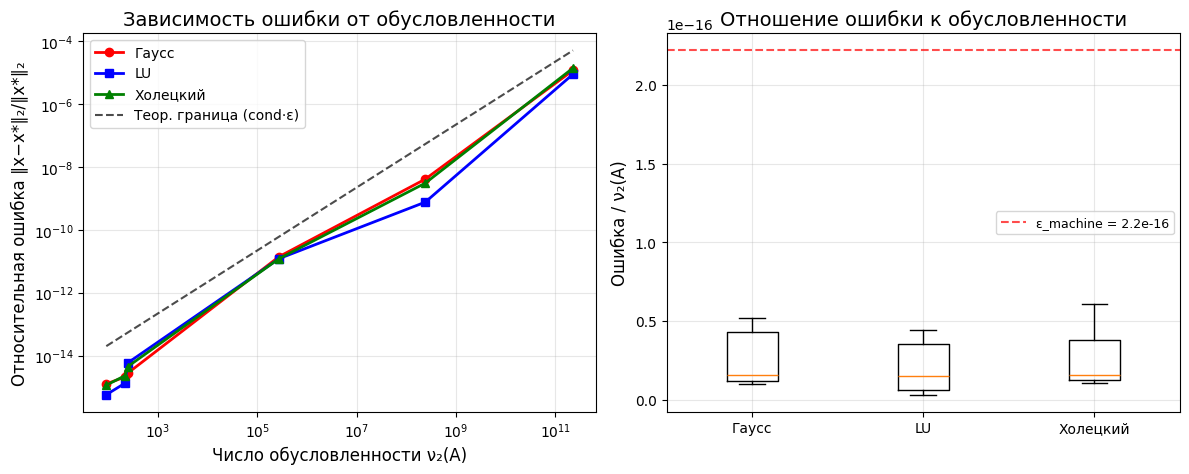

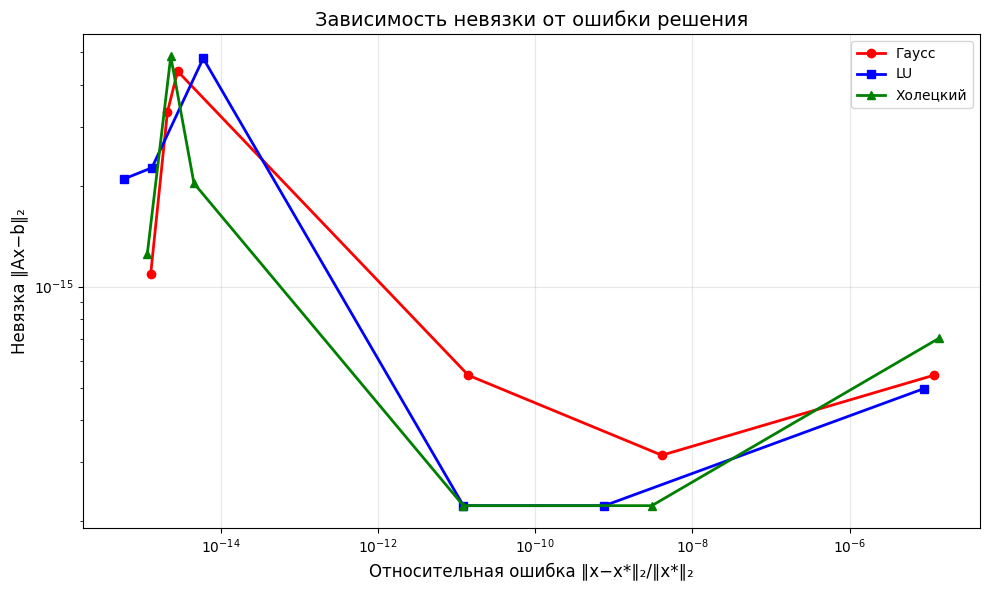


**********************************************************************
АНАЛИЗ ТЕОРЕТИЧЕСКОЙ ГРАНИЦЫ ОШИБКИ
**********************************************************************
Машинная точность ε = 2.2e-16
Теоретическая граница ошибки: ∥Δx∥/∥x∥ ≤ cond(A) · ε

Примеры для различных cond(A):
**************************************************
cond(A) = 1.0e+02  -> граница ошибки = 2.2e-14  (ХОРОШАЯ)
cond(A) = 1.0e+04  -> граница ошибки = 2.2e-12  (ХОРОШАЯ)
cond(A) = 1.0e+06  -> граница ошибки = 2.2e-10  (ХОРОШАЯ)
cond(A) = 1.0e+08  -> граница ошибки = 2.2e-08  (ХОРОШАЯ)
cond(A) = 1.0e+10  -> граница ошибки = 2.2e-06  (УМЕРЕННАЯ)
cond(A) = 1.0e+12  -> граница ошибки = 2.2e-04  (УМЕРЕННАЯ)
cond(A) = 1.0e+14  -> граница ошибки = 2.2e-02  (УМЕРЕННАЯ)
cond(A) = 1.0e+16  -> граница ошибки = 2.2e+00  (ПЛОХАЯ)


In [181]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

def analyze_errors_and_condition():
    """
    Анализ относительной ошибки, невязки и их зависимости от числа обусловленности
    """
    print("АНАЛИЗ ОШИБОК И ЗАВИСИМОСТИ ОТ ОБУСЛОВЛЕННОСТИ")
    print("*" * 70)
    
    # Исследуем матрицы разной размерности и обусловленности
    sizes = [3, 4, 5, 6, 7, 8]
    
    # Словари для хранения данных по методам
    method_data = {
        'Гаусс': {'conditions': [], 'errors': [], 'residuals': []},
        'LU': {'conditions': [], 'errors': [], 'residuals': []},
        'Холецкий': {'conditions': [], 'errors': [], 'residuals': []}
    }
    
    print(f"{'n':<3} {'cond(A)':<12} {'Метод':<10} {'Ошибка':<12} {'Невязка':<12} {'cond*ошибка':<12}")
    print("-" * 70)
    
    for n in sizes:
        # Создаем матрицу с контролируемой обусловленностью
        if n <= 5:
            # Для малых n используем матрицу Гильберта (плохая обусловленность)
            A = hilbert_matrix(n)
            A = A.T @ A  # Делаем SPD
        else:
            # Для больших n создаем случайную SPD матрицу
            B = np.random.randn(n, n)
            A = B.T @ B + 0.01 * np.eye(n)  # α = 0.01 для умеренной обусловленности
        
        # Истинное решение
        x_true = np.ones(n)
        b = A @ x_true
        
        # Число обусловленности
        cond_A = np.linalg.cond(A)
        
        # Тестируем методы
        methods = [
            ('Гаусс', gaussian_with_partial_choice),
            ('LU', solve_lu),
            ('Холецкий', solve_cholesky)
        ]
        
        for method_name, method in methods:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                try:
                    x_calculated = method(A.copy(), b.copy())
                    
                    if x_calculated is not None:
                        # Относительная ошибка
                        relative_error = np.linalg.norm(x_calculated - x_true) / np.linalg.norm(x_true)
                        
                        # Невязка
                        residual = np.linalg.norm(A @ x_calculated - b)
                        
                        # Сохраняем результаты
                        method_data[method_name]['conditions'].append(cond_A)
                        method_data[method_name]['errors'].append(relative_error)
                        method_data[method_name]['residuals'].append(residual)
                        
                        # Выводим результаты
                        cond_error_product = cond_A * relative_error
                        print(f"{n:<3} {cond_A:<12.2e} {method_name:<10} {relative_error:<12.2e} {residual:<12.2e} {cond_error_product:<12.2e}")
                        
                except Exception as e:
                    print(f"{n:<3} {cond_A:<12.2e} {method_name:<10} {'ошибка':<12} {'-':<12} {'-':<12}")
    
    # Построение графиков
    plot_error_vs_condition(method_data)
    plot_residual_vs_error(method_data)

def plot_error_vs_condition(method_data):
    """
    Построение зависимости ошибки от числа обусловленности
    """
    plt.figure(figsize=(12, 5))
    
    # График 1: Зависимость ошибки от обусловленности
    plt.subplot(1, 2, 1)
    
    colors = {'Гаусс': 'red', 'LU': 'blue', 'Холецкий': 'green'}
    markers = {'Гаусс': 'o', 'LU': 's', 'Холецкий': '^'}
    
    for method_name, data in method_data.items():
        if data['errors'] and data['conditions']:
            # Сортируем данные по обусловленности для правильного соединения точек
            sorted_data = sorted(zip(data['conditions'], data['errors']), key=lambda x: x[0])
            conds_sorted, errors_sorted = zip(*sorted_data)
            
            plt.loglog(conds_sorted, errors_sorted, 
                      color=colors[method_name], marker=markers[method_name], 
                      label=method_name, linewidth=2, markersize=6, linestyle='-')
    
    # Теоретическая граница (cond(A) * ε_machine)
    machine_epsilon = np.finfo(float).eps
    
    # Для построения теоретической границы используем диапазон условий из данных
    all_conditions = []
    for data in method_data.values():
        all_conditions.extend(data['conditions'])
    
    if all_conditions:
        min_cond = min(all_conditions)
        max_cond = max(all_conditions)
        cond_range = np.logspace(np.log10(min_cond), np.log10(max_cond), 100)
        theoretical = cond_range * machine_epsilon
        plt.loglog(cond_range, theoretical, 'k--', 
                  label=f'Теор. граница (cond·ε)', alpha=0.7, linewidth=1.5)
    
    plt.xlabel('Число обусловленности ν₂(A)', fontsize=12)
    plt.ylabel('Относительная ошибка ∥x−x*∥₂/∥x*∥₂', fontsize=12)
    plt.title('Зависимость ошибки от обусловленности', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # График 2: Отношение ошибки к обусловленности
    plt.subplot(1, 2, 2)
    
    ratios_data = []
    labels = []
    
    for method_name, data in method_data.items():
        if data['errors'] and data['conditions']:
            ratios = []
            for cond, error in zip(data['conditions'], data['errors']):
                if error > 0:
                    ratios.append(error / cond)
            
            if ratios:
                ratios_data.append(ratios)
                labels.append(method_name)
    
    if ratios_data:
        plt.boxplot(ratios_data, labels=labels)
        plt.axhline(y=machine_epsilon, color='r', linestyle='--', 
                   label=f'ε_machine = {machine_epsilon:.1e}', alpha=0.7)
        plt.ylabel('Ошибка / ν₂(A)', fontsize=12)
        plt.title('Отношение ошибки к обусловленности', fontsize=14)
        plt.legend(fontsize=9)
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, 'Нет данных для построения', 
                ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
        plt.title('Отношение ошибки к обусловленности\n(нет данных)', fontsize=14)
    
    plt.tight_layout()
    plt.show()

def plot_residual_vs_error(method_data):
    """
    Построение зависимости невязки от ошибки
    """
    plt.figure(figsize=(10, 6))
    
    colors = {'Гаусс': 'red', 'LU': 'blue', 'Холецкий': 'green'}
    markers = {'Гаусс': 'o', 'LU': 's', 'Холецкий': '^'}
    
    for method_name, data in method_data.items():
        if data['errors'] and data['residuals']:
            # Сортируем данные по ошибке для правильного соединения точек
            sorted_data = sorted(zip(data['errors'], data['residuals']), key=lambda x: x[0])
            errors_sorted, residuals_sorted = zip(*sorted_data)
            
            plt.loglog(errors_sorted, residuals_sorted, 
                      color=colors[method_name], marker=markers[method_name], 
                      label=method_name, linewidth=2, markersize=6, linestyle='-')
    
    plt.xlabel('Относительная ошибка ∥x−x*∥₂/∥x*∥₂', fontsize=12)
    plt.ylabel('Невязка ∥Ax−b∥₂', fontsize=12)
    plt.title('Зависимость невязки от ошибки решения', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_error_bound():
    """
    Анализ теоретической границы ошибки
    """
    print("\n" + "*" * 70)
    print("АНАЛИЗ ТЕОРЕТИЧЕСКОЙ ГРАНИЦЫ ОШИБКИ")
    print("*" * 70)
    
    # Теоретическая оценка: ∥Δx∥/∥x∥ ≤ cond(A) * (∥ΔA∥/∥A∥ + ∥Δb∥/∥b∥)
    machine_epsilon = np.finfo(float).eps
    
    print(f"Машинная точность ε = {machine_epsilon:.1e}")
    print(f"Теоретическая граница ошибки: ∥Δx∥/∥x∥ ≤ cond(A) · ε")
    print("\nПримеры для различных cond(A):")
    print("*" * 50)
    
    test_conditions = [1e2, 1e4, 1e6, 1e8, 1e10, 1e12, 1e14, 1e16]
    
    for cond in test_conditions:
        theoretical_bound = cond * machine_epsilon
        if theoretical_bound < 1e-6:
            status = "ХОРОШАЯ"
        elif theoretical_bound > 1:
            status = "ПЛОХАЯ"
        else:
            status = "УМЕРЕННАЯ"
        print(f"cond(A) = {cond:<8.1e} -> граница ошибки = {theoretical_bound:<8.1e} ({status})")

# Вспомогательные функции
def hilbert_matrix(n):
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            H[i, j] = 1.0 / (i + j + 1)
    return H

def gaussian_with_partial_choice(matrix, result):
    """Метод Гаусса с частичным выбором главного элемента"""
    n = len(result)
    Ab = np.hstack([matrix.astype(float), result.reshape(-1, 1).astype(float)])
    
    for i in range(n):
        max_row = np.argmax(np.abs(Ab[i:, i])) + i
        if max_row != i:
            Ab[[i, max_row]] = Ab[[max_row, i]]
        
        for j in range(i + 1, n):
            factor = Ab[j, i] / Ab[i, i]
            Ab[j, i:] -= factor * Ab[i, i:]
    
    answer = np.zeros(n)
    for i in range(n-1, -1, -1):
        answer[i] = (Ab[i, -1] - np.dot(Ab[i, i+1:n], answer[i+1:n])) / Ab[i, i]
    
    return answer

def lu_decomposition(A):
    n = A.shape[0]
    L = np.eye(n)
    U = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if j >= i:
                U[i, j] = A[i, j] - np.dot(L[i, :i], U[:i, j])
            if i > j:
                L[i, j] = (A[i, j] - np.dot(L[i, :j], U[:j, j])) / U[j, j]
    
    return L, U

def solve_lu(A, b):
    try:
        L, U = lu_decomposition(A)
        for i in range(U.shape[0]):
            if abs(U[i, i]) < 1e-12:
                raise ValueError("Нулевой диагональный элемент")
        
        n = len(b)
        y = np.zeros(n)
        y[0] = b[0] / L[0, 0]
        for k in range(1, n):
            y[k] = (b[k] - np.dot(L[k, :k], y[:k])) / L[k, k]
        
        x = np.zeros(n)
        x[-1] = y[-1] / U[-1, -1]
        for k in range(n-2, -1, -1):
            x[k] = (y[k] - np.dot(U[k, k+1:], x[k+1:])) / U[k, k]
        
        return x
        
    except ValueError as e:
        print("Ошибка LU-разложения:", e)
        return None

def cholesky_decomposition(A):
    n = A.shape[0]
    L = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i + 1):
            if i == j:
                sum_sq = np.sum(L[i, :j]**2)
                L[i, j] = np.sqrt(A[i, i] - sum_sq)
            else:
                sum_prod = np.sum(L[i, :j] * L[j, :j])
                L[i, j] = (A[i, j] - sum_prod) / L[j, j]
    
    return L

def solve_cholesky(A, b):
    L = cholesky_decomposition(A)

    n = len(b)
    y = np.zeros(n)
    y[0] = b[0] / L[0, 0]
    for k in range(1, n):
        y[k] = (b[k] - np.dot(L[k, :k], y[:k])) / L[k, k]

    x = np.zeros(n)
    x[-1] = y[-1] / L[-1, -1]
    for k in range(n-2, -1, -1):
        x[k] = (y[k] - np.dot(L[k+1:, k], x[k+1:])) / L[k, k]
    
    return x

# Основная программа
if __name__ == "__main__":
    print("ИССЛЕДОВАНИЕ ОШИБОК И ЗАВИСИМОСТИ ОТ ОБУСЛОВЛЕННОСТИ")
    print("=" * 70)
    
    analyze_errors_and_condition()
    analyze_error_bound()